# Phase 0: Explore nuScenes Data

Goal: Understand the dataset structure, scene IDs, and frame organization. This is foundation work before we write the formal data loader.

In [9]:
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# nuScenes devkit
from nuscenes import NuScenes

print("Imports successful!")

Imports successful!


## Step 1: Load the Dataset

In [10]:
import json
import os
from pathlib import Path

data_path = "/Volumes/BIggen/AV/data/nuscenes/v1.0-mini"

# Load the metadata JSON files directly
with open(os.path.join(data_path, 'scene.json')) as f:
    scenes = json.load(f)

with open(os.path.join(data_path, 'sample.json')) as f:
    samples = json.load(f)

with open(os.path.join(data_path, 'sample_data.json')) as f:
    sample_data = json.load(f)

print(f"Loaded {len(scenes)} scenes")
print(f"Loaded {len(samples)} samples")
print(f"Loaded {len(sample_data)} sample_data records")
print("\nReady to explore!")

Loaded 10 scenes
Loaded 404 samples
Loaded 31206 sample_data records

Ready to explore!


## Step 2: Understand Scenes and Samples

In [12]:
print(f"Total scenes: {len(scenes)}")
print(f"Total samples: {len(samples)}")
print()

# Look at the first scene
first_scene = scenes[0]
print("First scene info:")
print(json.dumps(first_scene, indent=2))

Total scenes: 10
Total samples: 404

First scene info:
{
  "token": "cc8c0bf57f984915a77078b10eb33198",
  "log_token": "7e25a2c8ea1f41c5b0da1e69ecfa71a2",
  "nbr_samples": 39,
  "first_sample_token": "ca9a282c9e77460f8360f564131a8af5",
  "last_sample_token": "ed5fc18c31904f96a8f0dbb99ff069c0",
  "name": "scene-0061",
  "description": "Parked truck, construction, intersection, turn left, following a van"
}


## Step 3: Extract Scene IDs and Frame Structure

**This is critical for our data split strategy.** Each scene is a contiguous driving sequence. All frames from one scene MUST stay together in train/val/test splits.

In [13]:
# Create lookup: scene token -> scene name
scene_token_to_name = {s['token']: s['name'] for s in scenes}

# Create lookup: sample token -> sample data
sample_token_to_data = {s['token']: s for s in samples}
sample_data_token_to_file = {sd['token']: sd for sd in sample_data}

# Create lookup: scene token -> first sample token
scene_token_to_first_sample = {s['token']: s['first_sample_token'] for s in scenes}

print(f"Scenes (by name):")
for i, name in enumerate(sorted(scene_token_to_name.values())):
    print(f"  {i}: {name}")

Scenes (by name):
  0: scene-0061
  1: scene-0103
  2: scene-0553
  3: scene-0655
  4: scene-0757
  5: scene-0796
  6: scene-0916
  7: scene-1077
  8: scene-1094
  9: scene-1100


In [22]:
# Debug: print a sample structure
sample_token = scenes[0]['first_sample_token']
sample = sample_token_to_data[sample_token]
# Debug: What does sample_data actually look like?
print("Sample data record structure:")
print(json.dumps(sample_data[0], indent=2))

Sample data record structure:
{
  "token": "5ace90b379af485b9dcb1584b01e7212",
  "sample_token": "39586f9d59004284a7114a68825e8eec",
  "ego_pose_token": "5ace90b379af485b9dcb1584b01e7212",
  "calibrated_sensor_token": "f4d2a6c281f34a7eb8bb033d82321f79",
  "timestamp": 1532402927814384,
  "fileformat": "pcd",
  "is_key_frame": false,
  "height": 0,
  "width": 0,
  "filename": "sweeps/RADAR_FRONT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT__1532402927814384.pcd",
  "prev": "f0b8593e08594a3eb1152c138b312813",
  "next": "978db2bcdf584b799c13594a348576d2"
}


In [23]:
frames = []

# Create a lookup: sample_token -> list of sample_data for that sample
sample_to_sensor_data = {}
for sd in sample_data:
    sample_tok = sd['sample_token']
    if sample_tok not in sample_to_sensor_data:
        sample_to_sensor_data[sample_tok] = []
    sample_to_sensor_data[sample_tok].append(sd)

# Collect frames
for scene in scenes:
    scene_name = scene['name']
    sample_token = scene['first_sample_token']
    
    # Walk through all samples in this scene
    while sample_token:
        sample = sample_token_to_data[sample_token]
        
        # Find CAM_FRONT data for this sample (filter by filename)
        sensor_data_list = sample_to_sensor_data.get(sample_token, [])
        cam_front = [sd for sd in sensor_data_list if 'CAM_FRONT' in sd['filename']]
        
        if cam_front:
            image_path = os.path.join(data_path, cam_front[0]['filename'])
            frames.append({
                'path': image_path,
                'scene_id': scene_name,
            })
        
        # Next sample
        sample_token = sample['next'] if sample['next'] else None

print(f"Total frames collected: {len(frames)}")
print(f"\nFirst 10 frames:")
for i, f in enumerate(frames[:10]):
    print(f"  Frame {i}: scene={f['scene_id']}, file={Path(f['path']).name}")

Total frames collected: 404

First 10 frames:
  Frame 0: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
  Frame 1: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927762460.jpg
  Frame 2: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402928412460.jpg
  Frame 3: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402929112460.jpg
  Frame 4: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402929612460.jpg
  Frame 5: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402929762460.jpg
  Frame 6: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402930412460.jpg
  Frame 7: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402931112460.jpg
  Frame 8: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402931612460.jpg
  Frame 9: scene=scene-0061, file=n015-2018-07-24-11-22-45+0800__CAM_FRONT__15324

## Step 4: Check Scene Grouping

Verify that frames are properly grouped by scene.

In [24]:
# Count frames per scene
from collections import defaultdict

frames_per_scene = defaultdict(int)
for f in frames:
    frames_per_scene[f['scene_id']] += 1

print("Frames per scene:")
for scene_id, count in sorted(frames_per_scene.items()):
    print(f"  {scene_id}: {count} frames")

print(f"\nTotal: {sum(frames_per_scene.values())} frames across {len(frames_per_scene)} scenes")

Frames per scene:
  scene-0061: 39 frames
  scene-0103: 40 frames
  scene-0553: 41 frames
  scene-0655: 41 frames
  scene-0757: 41 frames
  scene-0796: 40 frames
  scene-0916: 41 frames
  scene-1077: 41 frames
  scene-1094: 40 frames
  scene-1100: 40 frames

Total: 404 frames across 10 scenes


## Step 5: Display Sample Frames

Let's look at what normal driving data looks like.

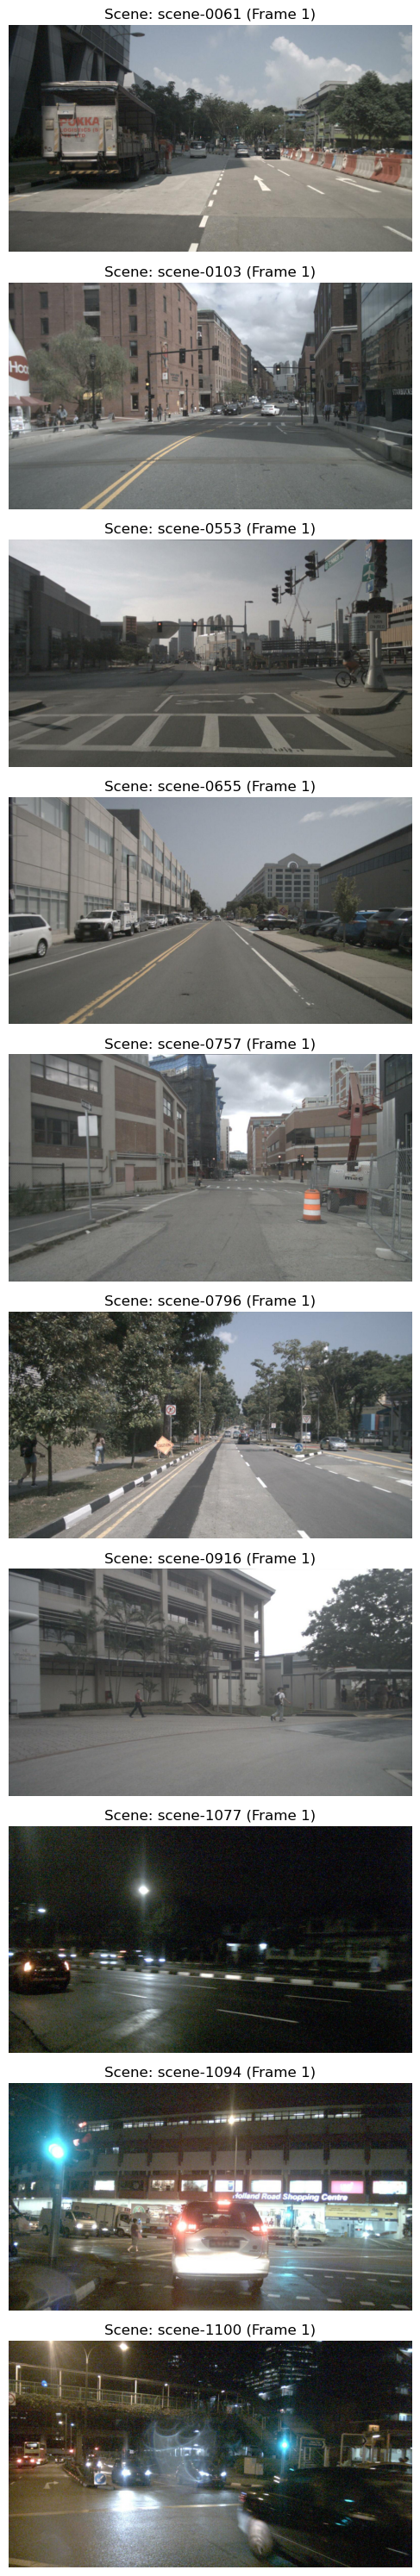

Saved to results/phase0_sample_frames.png


In [25]:
# Display the first frame from each scene
scene_ids = list(frames_per_scene.keys())
num_scenes = len(scene_ids)

fig, axes = plt.subplots(num_scenes, 1, figsize=(12, 3*num_scenes))
if num_scenes == 1:
    axes = [axes]

for idx, scene_id in enumerate(scene_ids):
    # Get first frame of this scene
    frame_of_scene = [f for f in frames if f['scene_id'] == scene_id][0]
    img_path = frame_of_scene['path']
    
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f"Scene: {scene_id} (Frame 1)")
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/Volumes/BIggen/AV/results/phase0_sample_frames.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved to results/phase0_sample_frames.png")

## Step 6: Sanity Checks

Verify the data looks reasonable for anomaly detection.

In [26]:
# Check that files actually exist
missing = [f for f in frames if not os.path.exists(f['path'])]
print(f"Missing files: {len(missing)} / {len(frames)}")

# Check image sizes
if len(frames) > 0:
    img = Image.open(frames[0]['path'])
    print(f"Image size: {img.size} (width x height)")
    print(f"Image mode: {img.mode}")

print("\nData looks good! Ready for dataset adapter.")

Missing files: 0 / 404
Image size: (1600, 900) (width x height)
Image mode: RGB

Data looks good! Ready for dataset adapter.


## Step 7: Summary for Data Adapter

Now we know:
1. Scene IDs: Use the scene `name` (e.g., "scene-0001") as the atomic grouping unit
2. Frames: Each sample has a CAM_FRONT image we can load
3. Structure: Walk through scenes → samples → sample_data to get image paths
4. Ground truth: We don't have anomaly labels yet (we'll use corner-case datasets for evaluation later)

Next: Write `src/data/nuscenes_loader.py` that returns Frame objects.

In [27]:
# Export frames as JSON for the next phase
frames_json = [
    {
        'path': f['path'],
        'scene_id': f['scene_id'],
    }
    for f in frames
]

with open('/Volumes/BIggen/AV/results/phase0_frames.json', 'w') as out:
    json.dump(frames_json, out, indent=2)

print(f"Saved {len(frames_json)} frames to results/phase0_frames.json")

Saved 404 frames to results/phase0_frames.json
